In [1]:
import pandas as pd

df = pd.read_csv(r"D:\6TH SEM\PROJECTS\TEXT MINING\news-bias-detection\data\bias_clean.csv")
df.head()

,url,topic,date,title,site,bias,page_text
0,https://www.npr.org/2021/01/01/952336030/what-...,general-news,2021-01-01,"What Got Us Through 2020? For Many, It Was Hob...",NPR (Online News),leaning-left,"What Got Us Through 2020? For Many, It Was Hob..."
1,https://www.cbsnews.com/news/new-years-eve-gat...,general-news,2020-12-31,New Year's Eve gatherings could accelerate COV...,CBS News (Online),leaning-left,New Year's Eve gatherings could accelerate COV...
2,https://nypost.com/2020/12/31/heres-how-countr...,general-news,2020-12-31,Here’s how countries around the world are ring...,New York Post (News),leaning-right,Here’s how countries around the world are ring...
3,https://www.theguardian.com/world/2020/dec/31/...,coronavirus,2020-12-31,Wisconsin health worker 'deliberately spoiled ...,The Guardian,left,Police in Wisconsin said on Thursday evening t...
4,https://www.foxnews.com/us/wis-hospital-intent...,coronavirus,2020-12-31,Wisconsin hospital employee 'intentionally' re...,Fox News Digital,right,A Wisconsin-based hospital on Wednesday said a...


In [2]:
def map_bias(label):
    if label in ['left', 'leaning-left']:
        return 'Left'
    elif label in ['right', 'leaning-right']:
        return 'Right'
    else:
        return 'Center'

df['final_bias'] = df['bias'].apply(map_bias)

In [3]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special chars
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['processed_text'] = df['page_text'].apply(preprocess)

[nltk_data] Downloading package stopwords to C:\Users\Preethi
[nltk_data]     S\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
X = df['processed_text']
y = df['final_bias']

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [8]:
#Logoistic 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
#naive bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [10]:
#svm
from sklearn.svm import LinearSVC

svm = LinearSVC(class_weight='balanced')
svm.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [11]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SVM": svm
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Logistic Regression
Accuracy: 0.6852791878172588
              precision    recall  f1-score   support

      Center       0.46      0.56      0.51       296
        Left       0.72      0.70      0.71       976
       Right       0.75      0.71      0.73       895

    accuracy                           0.69      2167
   macro avg       0.64      0.66      0.65      2167
weighted avg       0.69      0.69      0.69      2167


Naive Bayes
Accuracy: 0.5749884633133364
              precision    recall  f1-score   support

      Center       0.70      0.02      0.05       296
        Left       0.53      0.83      0.65       976
       Right       0.67      0.48      0.56       895

    accuracy                           0.57      2167
   macro avg       0.63      0.44      0.42      2167
weighted avg       0.61      0.57      0.53      2167


SVM
Accuracy: 0.6935856022150438
              precision    recall  f1-score   support

      Center       0.52      0.46      0.49       296
   

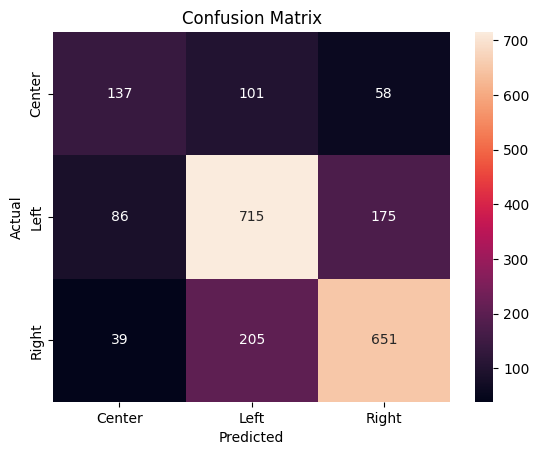

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = svm  # change if needed

cm = confusion_matrix(y_test, best_model.predict(X_test_tfidf))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
import sys
!"{sys.executable}" -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Preethi S\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [16]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: SVM


In [19]:
import pickle

# Save best model
pickle.dump(svm, open(r"D:\6TH SEM\PROJECTS\TEXT MINING\news-bias-detection\models\bias_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open(r"D:\6TH SEM\PROJECTS\TEXT MINING\news-bias-detection\models\tfidf_vectorizer.pkl", "wb"))

# Save label encoder
pickle.dump(le, open(r"D:\6TH SEM\PROJECTS\TEXT MINING\news-bias-detection\models\label_encoder.pkl", "wb"))

In [20]:
def predict_bias(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    pred = svm.predict(vec)
    return le.inverse_transform(pred)[0]

In [21]:
sample = df['page_text'].iloc[0]
print(predict_bias(sample))

Left


In [24]:
current_data = pd.read_csv(r"D:\6TH SEM\PROJECTS\TEXT MINING\news-bias-detection\data\datalive_cleaned_data.csv")
df1 = pd.DataFrame(current_data)
print(df1.head())

                                                 url  \
0         https://www.bbc.co.uk/sounds/play/m002sg2c   
1  https://www.theverge.com/column/888907/ai-cult...   
2     https://www.bbc.com/news/articles/cwygpdjq9jjo   
3     https://www.bbc.com/news/articles/c0rj4nvw07do   
4     https://www.bbc.com/news/articles/clyxwgll758o   

                                               title        date       site  \
0  Taking Back Control: Why ‘Agency’ Could Be The...  2026-03-12   BBC News   
1  AI is now part of the culture wars — and real ...  2026-03-04  The Verge   
2  Sir John Curtice: Greens' win means future of ...  2026-02-27   BBC News   
3  Starmer seeks to carve out distinct UK approac...  2026-03-02   BBC News   
4  Iranian footballer says 'everything will be fi...  2026-03-16   BBC News   

      bias                                          page_text  \
0   center  Available for over a year\r\n\r\nOn this week’...   
1  unknown  is a Senior Reporter for The Verge and author 

In [27]:
sample1 = df1['page_text'].iloc[]
print(predict_bias(sample1))

Center
